In [15]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [16]:
def Plot_CMB_Map(Map_to_Plot,c_min,c_max,X_width,Y_width):
    print("map mean:",np.mean(Map_to_Plot),"map rms:",np.std(Map_to_Plot))
    
    plt.gcf().set_size_inches(10, 10)
    im = plt.imshow(Map_to_Plot, interpolation='bilinear', origin='lower',cmap=cm.RdBu_r)
    # im.set_clim(c_min,c_max)
    ax=plt.gca()
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    cbar = plt.colorbar(im, cax=cax)
    im.set_extent([0,X_width,0,Y_width])
    plt.ylabel('angle $[^\circ]$')
    plt.xlabel('angle $[^\circ]$')
    cbar.set_label('tempearture [uK]', rotation=270)
    plt.show()

def calc_white_noise(kgrid, loc=0., scale=1.):
    white_noise = np.zeros(kgrid.shape, dtype=np.complex64)
    for i in range(kgrid.shape[0]):
        for j in range(kgrid.shape[1]):
            white_noise[i,j] = (np.random.normal(loc,scale)+1j*np.random.normal(loc,scale))/np.sqrt(2)
    return white_noise
      
def calc_primordial_power(kgrid, cosmo):
    pk = np.zeros_like(kgrid)
    idx = np.where(kgrid != 0)
    pfactor = cosmo['A']*cosmo['kpivot']**(1.-cosmo['ns'])
    pk[idx] = np.power(kgrid[idx], cosmo['ns']-4.)*pfactor
    pk[0,0] = 0
    return pk

def calc_non_gaussian(F_nl, field):
    return 5/3 * F_nl * field**2

def apply_linear_power_or_transfer(delta_c,kgrid,kLin,PLin_or_TFLin):
    for i in np.arange(kgrid.shape[0]):
        delta_c[i] *= np.interp(kgrid[i],kLin,PLin_or_TFLin)
    delta_c[0,0] = 0

In [17]:
def calculate_2d_spectrum(Map,delta_ell,ell_max, kgrid=None):
    if kgrid is None:
        ones = np.ones(grid)
        inds  = (np.arange(grid)+.5 - grid/2.) /(grid-1.)
        kX = np.outer(ones,inds) / pix_size_rad
        kY = np.transpose(kX)
        K = np.sqrt(kX**2. + kY**2.)
        ell_scale_factor = 2 * np.pi
    else:
        K = kgrid
        ell_scale_factor = d_A
        
    ell2d = K * ell_scale_factor
    print(f'ell2d min: {ell2d.min()} max: {ell2d.max()}')
    print(f'pix_size: {pix_size}')

    # make an array to hold the power spectrum results
    N_bins = int(ell_max/delta_ell)
    ell_array = np.arange(N_bins)
    CL_array = np.zeros(N_bins)
    
    # get the 2d fourier transform of the map
    FMap1 = np.fft.ifft2(Map)
    FMap2 = np.fft.ifft2(Map)
    PSMap = np.real(np.conj(FMap1) * FMap2)
    
    # PSMap =  np.fft.ifft2(np.conj(np.abs(Map)) * np.abs(Map)).real

    # fill out the spectra
    i = 0
    while (i < N_bins):
        ell_array[i] = (i + 0.5) * delta_ell
        inds_in_bin = ((ell2d >= (i* delta_ell)) * (ell2d < ((i+1)* delta_ell))).nonzero()
        if np.sum(inds_in_bin) != 0:
            CL_array[i] = np.mean(PSMap[inds_in_bin])
        # print(i, ell_array[i], inds_in_bin, CL_array[i])
        i = i + 1
        
    # return the power spectrum and ell bins
    return(ell_array, CL_array * 2*np.sqrt(pix_size_rad))

def plot_cls(map, kgrid=None, title=None):            
    ls, cls = calculate_2d_spectrum(map, 10, 5000, kgrid)
    cls *= ls * (ls + 1) / (2 * np.pi**2)
    m = (ls > 2) & (cls > 0)
    plt.plot(ls[m], cls[m])
    if title is not None:
        plt.title(title)
    plt.show()

In [18]:
cosmo = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'A': 2*np.pi*np.pi*2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 5000,
    'accuracy_boost': 4,
}
h = cosmo['h']

grid = 128 #Number of grid cells
d_A = 13897 # Angular diameter distance in Mpc
box_size = 1000. #Size of periodic box e.g. in Mpc/h

cell_size = box_size / grid #Physical size of grid-cell
kF = 2*np.pi / box_size #Fundamental frequency
kNyq = kF * grid / 2 #Nyquist frequency of the grid

theta = (box_size*h) / d_A * 60 * 180 / np.pi #Field of view in arcminutes
pix_size = theta / grid #Size of pixel in arcminutes
pix_size_rad = pix_size / 60 * np.pi / 180 #Size of pixel in radians

kx = 2 * np.pi * np.fft.fftfreq( grid, cell_size)
ky = 2 * np.pi * np.fft.rfftfreq(grid, cell_size)
kmesh = np.meshgrid(kx,ky,indexing="ij")
kgrid = np.sqrt(kmesh[0]**2 + kmesh[1]**2)
khgrid = kgrid * h

print(f'angular size (arcmin): {theta}, pix size (arcmin): {pix_size} in rad: {pix_size_rad}')

angular size (arcmin): 166.01222262889638, pix size (arcmin): 1.296970489288253 in rad: 0.0003772734223213643


In [19]:
density_field = calc_white_noise(khgrid)
density_field *=  np.sqrt( calc_primordial_power(khgrid, cosmo) ) * grid**2/(box_size/h)**1.5
density_field[kgrid > kNyq] = 0.+0.j

real_field = np.fft.irfft2(density_field).real
real_field += calc_non_gaussian(1, real_field)
density_field = np.fft.rfft2(real_field)

kLin, TFLin = np.loadtxt("data/linear_thomas/LinearTransfer.dat")[:,[0,1]].T
apply_linear_power_or_transfer(density_field, kgrid, kLin, TFLin)

map = np.fft.irfft2(density_field).real

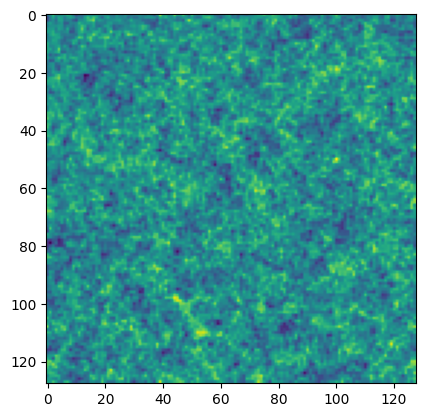

map mean: -3.469446951953614e-18 map rms: 1.0


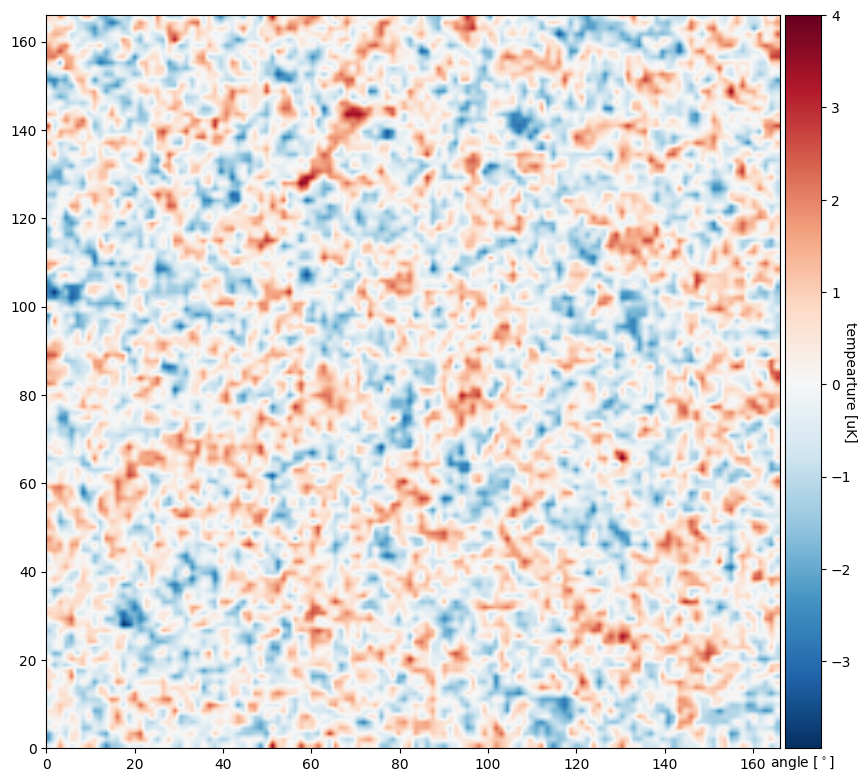

ell2d min: 92.726728552642 max: 11776.294526185535
pix_size: 1.296970489288253


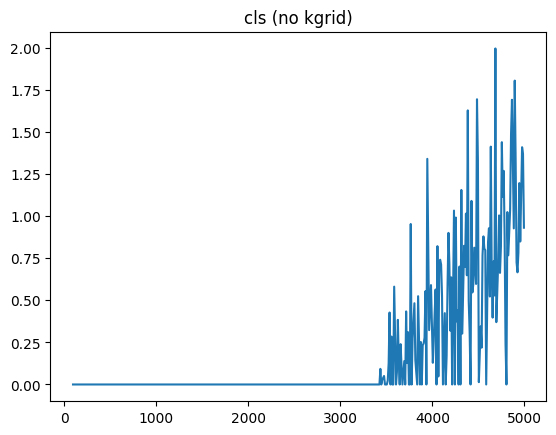

ell2d min: 0.0 max: 7903.071256523113
pix_size: 1.296970489288253


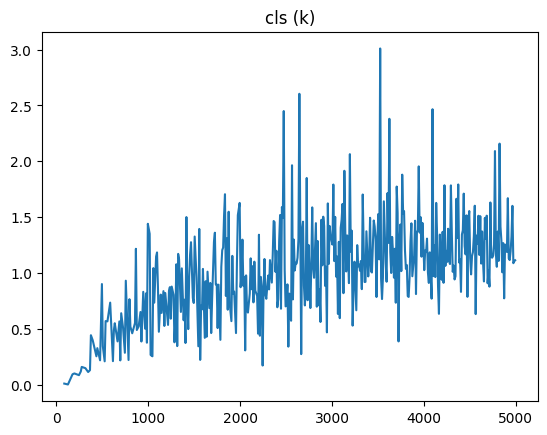

ell2d min: 0.0 max: 5303.751120252662
pix_size: 1.296970489288253


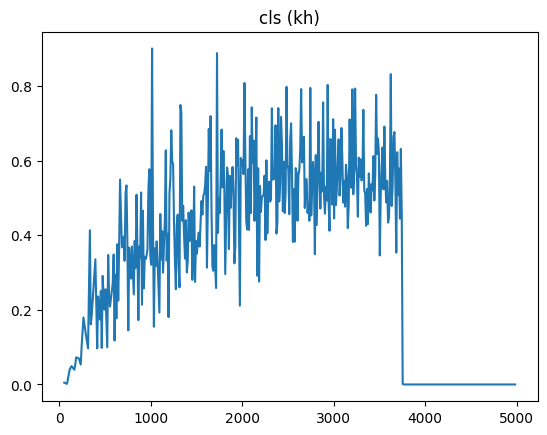

In [20]:
map = (map - map.mean()) / np.std(map)
plt.imshow(map)
plt.show()

Plot_CMB_Map(map, -400, 400, theta, theta)

plot_cls(map, title='cls (no kgrid)')
plot_cls(map, title='cls (k)', kgrid=kgrid)
plot_cls(map, title='cls (kh)', kgrid=khgrid)

[ CMBField -             __init__() ] | INFO : Setting CAMB parameters based on provided cosmology:
{'h': 0.6711, 'r': 0, 'As': 2.13e-09, 'A': 4.204451474864066e-08, 'ns': 0.9624, 'kpivot': 0.05, 'z_recomb': 1090.48, 'ombh2': 0.02233, 'omch2': 0.1198, 'tau': 0.0561, 'lmax': 5000, 'accuracy_boost': 4}
[ CMBField -            init_camb() ] | INFO : d_A: 13892.174976174396, angular size: 166.06988191773343
[ CMBField -             __init__() ] | INFO : Finished generating CMBField with resolution 128, box size 1000.0 Mpc/h, cell size 7.8125
[ CMBField -  calc_transfer_field() ] | INFO : Calculating transfer function... that might take a while...
[ CMBField -  calc_transfer_field() ] | INFO : Done!
map mean: -6.462348535570529e-27 map rms: 3.323213375615245e-10


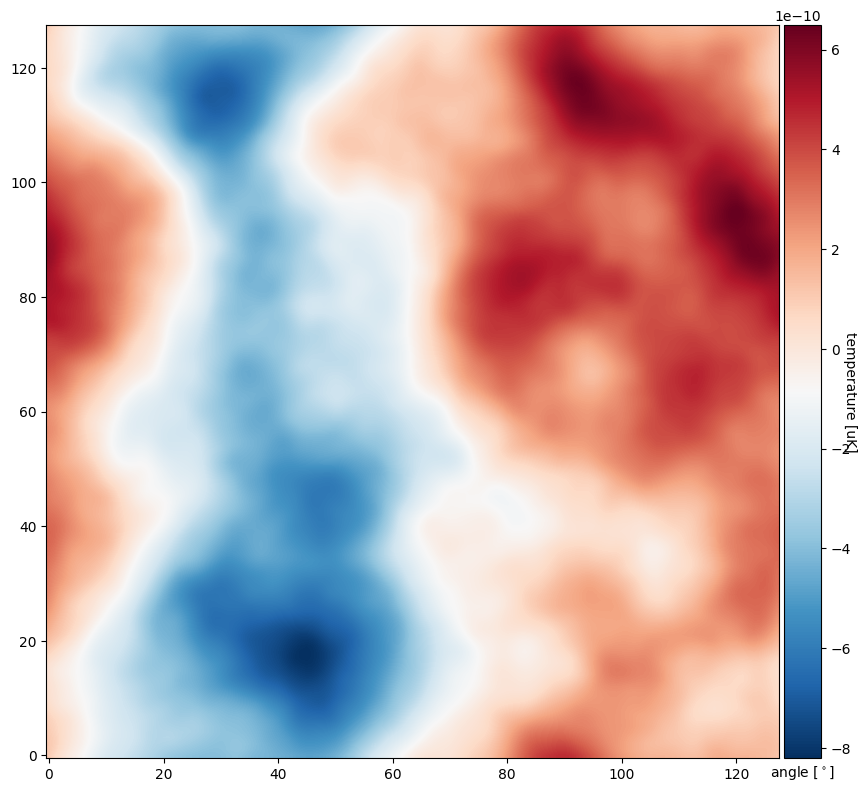

[ CMBField -        calculate_cls() ] | INFO : lmin: 58.57837931635939, lmax: 3749.016276247001


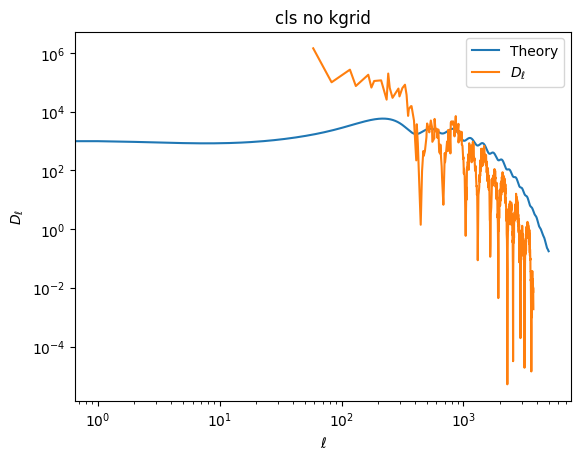

[ CMBField -        calculate_cls() ] | INFO : lmin: 58.57837931635939, lmax: 3749.016276247001


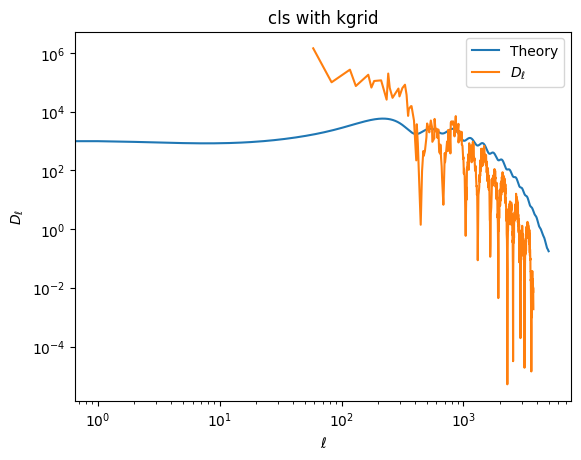

[ CMBField -        calculate_cls() ] | INFO : lmin: 58.57837931635939, lmax: 3749.016276247001


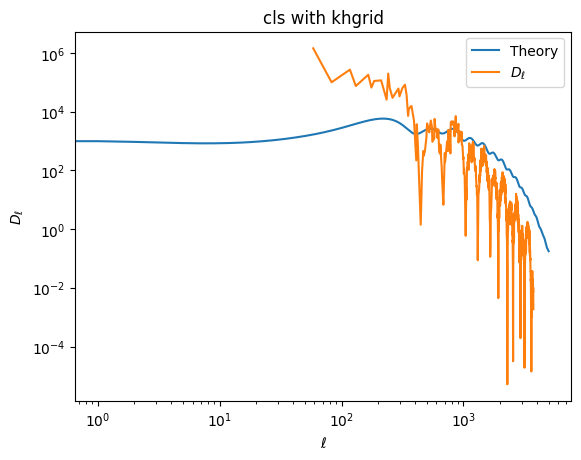

In [21]:
from CMBField import CMBField
from logging import INFO

field = CMBField(box_size, grid, cosmo_params=cosmo, log_level=INFO)
map = field.GenerateField(f_nl=0.,seed=0)
field.Plot_CMB_Map(map, -400, 400, theta, theta)

field.plot_cls(title='cls no kgrid')
field.plot_cls(title='cls with kgrid', kgrid=field.kgrid)
field.plot_cls(title='cls with khgrid', kgrid=field.khgrid)